# Digital Twin State - Streaming Acquisition & Aggregation

**Rubric target:** *Project Data, Streaming, Aggregation*
> "Define digital twin state relevant to your digital twin problem. Demonstrate streaming
> acquisition of multiple real data streams and its aggregation, conversion to digital
> twin state."

## What this notebook does

This version works directly from **`InfluxDB.xlsx`** - the raw annotated CSV export of a
Flux query pulled straight out of the InfluxDB bucket that our Node-RED pipeline has been
writing to. It contains real, already-captured sensor telemetry from the BH1750 +
STM32 rig (`lux`, `predicted_current`, `measured_current`, `error`), one row per field per
minute over the capture window.

It does **not** connect to a live MQTT broker and does **not** require a local
InfluxDB/Grafana docker stack - it uses the same real data those systems already hold,
replayed in timestamp order to demonstrate:

1. an explicit **digital twin state** definition,
2. **streaming acquisition** - messages validated and ingested one at a time, in arrival
   order, exactly as a live subscriber callback would handle them, and
3. **aggregation** of that stream into fixed time windows, converting many individual
   readings into a single digital twin state per window.

**Before running:** put `InfluxDB.xlsx` in the same folder as this notebook (or update
`DATA_PATH` below).

## 1. Setup

In [3]:
!pip install openpyxl -q

import json
import time
import queue
import threading
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl

DATA_PATH = "InfluxDB.xlsx"   # update this path if your file lives elsewhere

print("Libraries ready.")


Libraries ready.


## 2. Load the Raw InfluxDB Export

`InfluxDB.xlsx` is a Flux query result saved to Excel - it's an **annotated CSV**, not a
plain table. It has `#group` / `#datatype` / `#default` annotation rows, a real header row
(`result, table, _start, _stop, _time, _value, _field, _measurement`), and then one row per
`(timestamp, field)` pair. There's also a trailing error block, because the original query
also tried to `mean()`-aggregate the `status` field, which is a string - InfluxDB correctly
rejected that, so it never made it into this export.

The function below parses that structure into a clean, tidy dataframe.

In [4]:
def load_influx_export(path, sheet_name=None):
    """Parse an InfluxDB Flux-query annotated-CSV export (saved as .xlsx) into a tidy
    long-format dataframe with columns: _time, _value, _field, _measurement, table.
    Skips #group/#datatype/#default annotation lines and any trailing error/reference
    blocks (e.g. a field InfluxDB couldn't aggregate).
    """
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb[sheet_name] if sheet_name else wb[wb.sheetnames[0]]
    rows = list(ws.iter_rows(values_only=True))

    records = []
    header = None
    for row in rows:
        first = row[0]
        if isinstance(first, str) and first.startswith("#"):
            continue
        if all(v is None for v in row):
            header = None
            continue
        if first is None and row[1] == "result":
            header = row
            continue
        if header is None:
            continue
        records.append(dict(zip(header, row)))

    df = pd.DataFrame(records)
    if "result" in df.columns:
        df = df[df["result"].isna()]          # drops the trailing Influx error/reference rows
    df = df.dropna(subset=["_time", "_value", "_field"])
    df["_time"] = pd.to_datetime(df["_time"], format="mixed", utc=True)
    df["_value"] = df["_value"].astype(float)
    return df.reset_index(drop=True)

raw_long = load_influx_export(DATA_PATH)
print(f"Loaded {len(raw_long)} raw (timestamp, field) readings.")
print("Fields present:", sorted(raw_long['_field'].unique()))
raw_long.head()


Loaded 648 raw (timestamp, field) readings.
Fields present: ['error', 'lux', 'measured_current', 'predicted_current']


,None,result,table,_start,_stop,_time,_value,_field,_measurement
0,None,None,0,2026-07-28T12:55:06.178412444Z,2026-07-28T15:55:06.178412444Z,2026-07-28 13:11:00+00:00,0.00200,error,photodetector_reading
1,None,None,0,2026-07-28T12:55:06.178412444Z,2026-07-28T15:55:06.178412444Z,2026-07-28 13:12:00+00:00,0.00110,error,photodetector_reading
2,None,None,0,2026-07-28T12:55:06.178412444Z,2026-07-28T15:55:06.178412444Z,2026-07-28 13:13:00+00:00,0.00940,error,photodetector_reading
3,None,None,0,2026-07-28T12:55:06.178412444Z,2026-07-28T15:55:06.178412444Z,2026-07-28 13:14:00+00:00,0.00135,error,photodetector_reading
4,None,None,0,2026-07-28T12:55:06.178412444Z,2026-07-28T15:55:06.178412444Z,2026-07-28 13:15:00+00:00,0.00470,error,photodetector_reading


In [5]:
# Pivot into one row per timestamp, one column per field -- this is the shape a live
# MQTT subscriber would see if it received one JSON message per timestamp containing
# all fields at once.
wide = raw_long.pivot_table(index="_time", columns="_field", values="_value").sort_index()
wide = wide.reset_index().rename(columns={"_time": "timestamp"})

print(f"{wide.shape[0]} distinct timestamps, fields: {list(wide.columns[1:])}")
wide.head()


162 distinct timestamps, fields: ['error', 'lux', 'measured_current', 'predicted_current']


_field,timestamp,error,lux,measured_current,predicted_current
0,2026-07-28 13:11:00+00:00,0.00200,1043.02125,6.57300,6.571125
1,2026-07-28 13:12:00+00:00,0.00110,131.45800,0.82915,0.828250
2,2026-07-28 13:13:00+00:00,0.00940,1827.16700,11.52080,11.511350
3,2026-07-28 13:14:00+00:00,0.00135,2265.33400,14.27300,14.271750
4,2026-07-28 13:15:00+00:00,0.00470,2477.45800,15.61260,15.608050


## 3. Define the Digital Twin State

This is the explicit state the digital twin maintains at any point in time - one record
per reading, capturing both the raw telemetry actually recorded by InfluxDB and the twin's
derived health verdict for that instant.

| State variable | Meaning | Source |
|---|---|---|
| `timestamp` | When the reading was taken | real (Influx `_time`) |
| `lux` | Light intensity seen by the BH1750 | real sensor data |
| `predicted_current` | Digital twin's model output: `I = K x Lux` | real (Influx) |
| `measured_current` | The circuit's "ground truth" reading | real (Influx) |
| `error` | `measured_current - predicted_current` | real (Influx) |
| `status` | `OK` if `\|error\| < ERROR_THRESHOLD`, else `FAULT` - the twin's derived health verdict | derived |

`status` isn't in the raw export (it's a string, so Influx's `mean()` aggregate can't
touch it - that's the trailing error block we skipped above), so the digital twin derives
it itself from `error`, which is exactly the kind of raw-data-to-twin-state conversion the
rubric is asking for.

In [6]:
ERROR_THRESHOLD = 1.0   # |error| >= this (mA) => FAULT

REQUIRED_RAW_FIELDS = ["timestamp", "lux", "predicted_current", "measured_current", "error"]

def to_digital_twin_state(raw_msg: dict) -> dict:
    """Validate + normalize one incoming reading into a digital twin state record.
    Returns None (and is dropped) if the message doesn't match the agreed schema --
    this is the 'fail case' half of the pipeline: malformed data never enters twin state.
    """
    missing = [f for f in REQUIRED_RAW_FIELDS if f not in raw_msg or pd.isna(raw_msg[f])]
    if missing:
        return None
    error = float(raw_msg["error"])
    return {
        "timestamp": raw_msg["timestamp"],
        "lux": float(raw_msg["lux"]),
        "predicted_current": float(raw_msg["predicted_current"]),
        "measured_current": float(raw_msg["measured_current"]),
        "error": error,
        "status": "FAULT" if abs(error) >= ERROR_THRESHOLD else "OK",
    }

print("Digital twin state schema defined. ERROR_THRESHOLD =", ERROR_THRESHOLD, "mA")


Digital twin state schema defined. ERROR_THRESHOLD = 1.0 mA


## 4. Streaming Acquisition - Replaying the Captured Stream

`test.mosquitto.org` already delivered this data to Node-RED in real time, and Node-RED
already wrote it to InfluxDB as it arrived - the pivoted table above is genuine streaming
sensor data, not something synthesized for this notebook.

To demonstrate the acquisition side of the pipeline explicitly, this cell **replays those
readings in their original timestamp order through the same producer/consumer pattern a
live MQTT client would use**: an emitter thread pushes one reading at a time onto a queue
with a short delay between them, and a consumer pulls each one off, validates it against
the digital twin state schema, and either accepts or rejects it - printed live so
acquisition + validation is visible happening message by message.

In [7]:
PLAYBACK_DELAY_SEC = 0.03   # per-message delay -- purely to make the "streaming" visible

_message_queue = queue.Queue()
_counts = {"received": 0, "rejected": 0}

def _emit_stream(records):
    for rec in records:
        _message_queue.put(rec)
        time.sleep(PLAYBACK_DELAY_SEC)
    _message_queue.put(None)   # sentinel: end of stream

raw_records = wide.to_dict("records")

emitter = threading.Thread(target=_emit_stream, args=(raw_records,), daemon=True)
emitter.start()

stream_records = []
print(f"Streaming {len(raw_records)} captured readings...\n")

while True:
    item = _message_queue.get()
    if item is None:
        break
    state = to_digital_twin_state(item)
    if state is None:
        _counts["rejected"] += 1
        print(f"[STREAM] Rejected malformed/incomplete message: {item}")
        continue
    _counts["received"] += 1
    stream_records.append(state)
    if _counts["received"] % 20 == 0 or _counts["received"] <= 3:
        print(f"[STREAM] {state['timestamp']}  lux={state['lux']:.1f}  "
              f"predicted={state['predicted_current']:.3f}mA  "
              f"measured={state['measured_current']:.3f}mA  status={state['status']}")

emitter.join()
print(f"\nStream complete. Accepted: {_counts['received']}, Rejected: {_counts['rejected']}")


Streaming 162 captured readings...

[STREAM] 2026-07-28 13:11:00+00:00  lux=1043.0  predicted=6.571mA  measured=6.573mA  status=OK
[STREAM] 2026-07-28 13:12:00+00:00  lux=131.5  predicted=0.828mA  measured=0.829mA  status=OK
[STREAM] 2026-07-28 13:13:00+00:00  lux=1827.2  predicted=11.511mA  measured=11.521mA  status=OK
[STREAM] 2026-07-28 13:34:00+00:00  lux=105.7  predicted=0.666mA  measured=0.669mA  status=OK
[STREAM] 2026-07-28 13:54:00+00:00  lux=144.2  predicted=0.908mA  measured=0.909mA  status=OK
[STREAM] 2026-07-28 14:14:00+00:00  lux=169.2  predicted=1.066mA  measured=1.076mA  status=OK
[STREAM] 2026-07-28 14:34:00+00:00  lux=139.5  predicted=0.879mA  measured=0.875mA  status=OK
[STREAM] 2026-07-28 14:54:00+00:00  lux=135.4  predicted=0.853mA  measured=0.856mA  status=OK
[STREAM] 2026-07-28 15:14:00+00:00  lux=136.0  predicted=0.857mA  measured=0.858mA  status=OK
[STREAM] 2026-07-28 15:34:00+00:00  lux=136.7  predicted=0.861mA  measured=0.864mA  status=OK
[STREAM] 2026-07-28 

In [8]:
df_stream = pd.DataFrame(stream_records).sort_values("timestamp").reset_index(drop=True)
print(f"Captured {len(df_stream)} valid digital twin state records.")
df_stream.head(10)


Captured 162 valid digital twin state records.


,timestamp,lux,predicted_current,measured_current,error,status
0,2026-07-28 13:11:00+00:00,1043.02125,6.571125,6.57300,0.00200,OK
1,2026-07-28 13:12:00+00:00,131.45800,0.828250,0.82915,0.00110,OK
2,2026-07-28 13:13:00+00:00,1827.16700,11.511350,11.52080,0.00940,OK
3,2026-07-28 13:14:00+00:00,2265.33400,14.271750,14.27300,0.00135,OK
4,2026-07-28 13:15:00+00:00,2477.45800,15.608050,15.61260,0.00470,OK
5,2026-07-28 13:16:00+00:00,3483.33000,21.945000,21.95330,0.00830,OK
6,2026-07-28 13:17:00+00:00,3483.33000,21.945000,21.93400,-0.01100,OK
7,2026-07-28 13:18:00+00:00,3483.33000,21.945000,21.95390,0.00895,OK
8,2026-07-28 13:19:00+00:00,3483.33000,21.945000,21.93015,-0.01485,OK
9,2026-07-28 13:20:00+00:00,331.04100,2.085650,2.07420,-0.01130,OK


## 5. Aggregation - Converting the Raw Stream into Windowed Digital Twin State

A raw stream of individual readings isn't yet "digital twin state" in a usable sense -
this step aggregates the stream into fixed time windows, the same kind of windowing
InfluxDB/Grafana would apply continuously in production. This is the "aggregation,
conversion to digital twin state" half of the rubric, done explicitly.

In [9]:
if len(df_stream) == 0:
    raise RuntimeError("No messages were accepted -- check DATA_PATH / the export contents.")

df_indexed = df_stream.set_index("timestamp")

WINDOW = "5min"

agg = df_indexed.resample(WINDOW).agg({
    "lux": "mean",
    "predicted_current": "mean",
    "measured_current": "mean",
    "error": ["mean", "max"],
})
agg.columns = ["_".join(col).strip("_") for col in agg.columns]
agg["message_count"] = df_indexed.resample(WINDOW).size()

def _window_status(sub_df):
    return "FAULT" if (sub_df["error"].abs() >= ERROR_THRESHOLD).any() else "OK"

agg["window_status"] = df_indexed.resample(WINDOW).apply(_window_status)
agg = agg.dropna(subset=["lux_mean"])

print(f"Aggregated {len(df_stream)} raw readings into {len(agg)} {WINDOW} digital twin "
      f"state windows.")
agg.reset_index()


Aggregated 162 raw readings into 34 5min digital twin state windows.


,timestamp,lux_mean,predicted_current_mean,measured_current_mean,error_mean,error_max,message_count,window_status
0,2026-07-28 13:10:00+00:00,1316.745062,8.295619,8.298987,0.003462,0.009400,4,OK
1,2026-07-28 13:15:00+00:00,3282.155600,20.677610,20.676790,-0.000780,0.008950,5,OK
2,2026-07-28 13:20:00+00:00,507.259947,3.195807,3.192548,-0.003118,0.011158,5,OK
3,2026-07-28 13:25:00+00:00,161.059917,1.014975,1.015636,0.000892,0.007333,2,OK
4,2026-07-28 13:30:00+00:00,126.019079,0.793822,0.792676,-0.001150,0.002950,4,OK
5,2026-07-28 13:35:00+00:00,105.007216,0.661890,0.666912,0.005355,0.013400,5,OK
6,2026-07-28 13:40:00+00:00,96.592200,0.608630,0.609120,0.000580,0.006700,5,OK
7,2026-07-28 13:45:00+00:00,144.170000,0.908000,0.907500,-0.000790,0.005100,5,OK
8,2026-07-28 13:50:00+00:00,144.170000,0.908000,0.912461,0.004167,0.010650,5,OK
9,2026-07-28 13:55:00+00:00,161.411600,1.016960,1.014570,-0.002380,0.008900,5,OK


## 6. Visualizing Raw Stream vs. Aggregated Digital Twin State

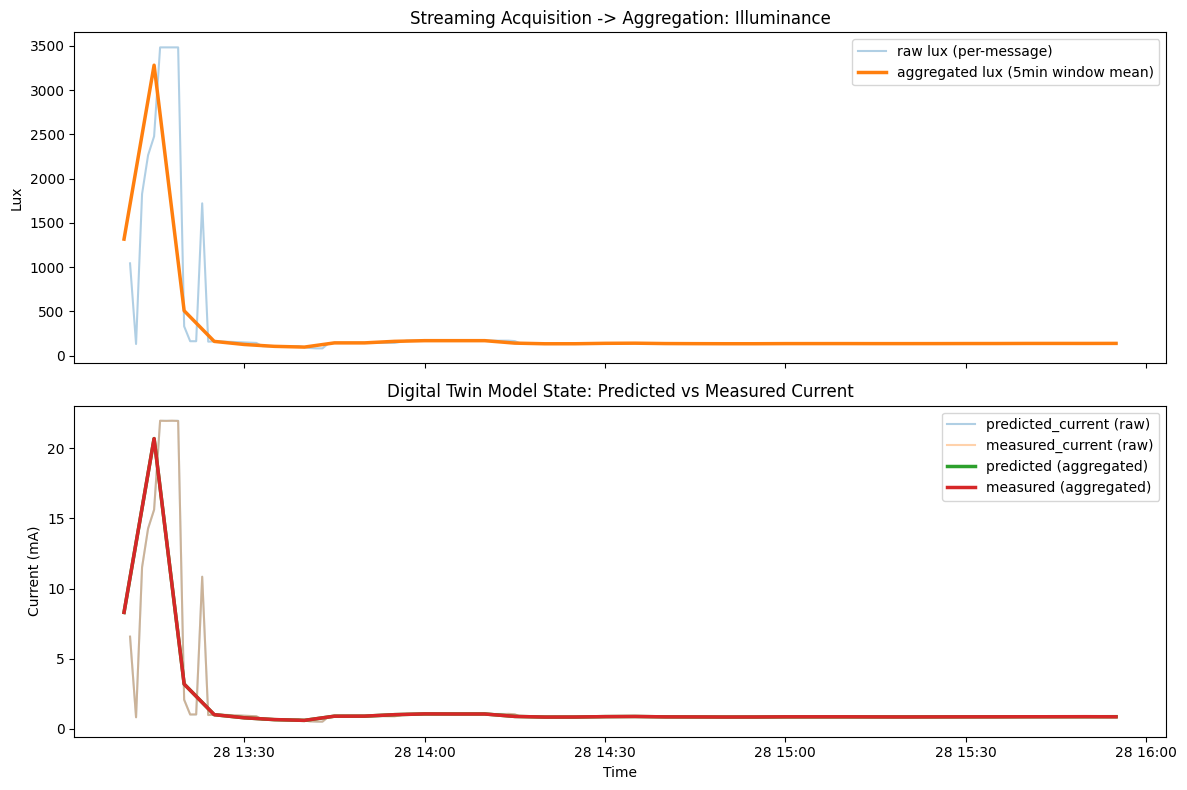

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df_stream["timestamp"], df_stream["lux"], alpha=0.35, label="raw lux (per-message)")
axes[0].plot(agg.index, agg["lux_mean"], linewidth=2.5, label=f"aggregated lux ({WINDOW} window mean)")
axes[0].set_ylabel("Lux")
axes[0].set_title("Streaming Acquisition -> Aggregation: Illuminance")
axes[0].legend()

axes[1].plot(df_stream["timestamp"], df_stream["predicted_current"], alpha=0.35, label="predicted_current (raw)")
axes[1].plot(df_stream["timestamp"], df_stream["measured_current"], alpha=0.35, label="measured_current (raw)")
axes[1].plot(agg.index, agg["predicted_current_mean"], linewidth=2.5, label="predicted (aggregated)")
axes[1].plot(agg.index, agg["measured_current_mean"], linewidth=2.5, label="measured (aggregated)")
axes[1].set_ylabel("Current (mA)")
axes[1].set_xlabel("Time")
axes[1].set_title("Digital Twin Model State: Predicted vs Measured Current")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Final Digital Twin State Summary

The most recent aggregated window represents the digital twin's **current best estimate**
of system state -- this is what would drive a live dashboard or a Blender/Omniverse
visualization at any given moment.

In [11]:
latest_window = agg.iloc[-1]

print("=== Current Digital Twin State (latest window) ===")
print(f"Timestamp        : {agg.index[-1]}")
print(f"Lux (mean)        : {latest_window['lux_mean']:.1f}")
print(f"Predicted Current : {latest_window['predicted_current_mean']:.4f} mA")
print(f"Measured Current  : {latest_window['measured_current_mean']:.4f} mA")
print(f"Error (mean)      : {latest_window['error_mean']:.4f} mA")
print(f"Error (max abs)   : {latest_window['error_max']:.4f} mA")
print(f"Status            : {latest_window['window_status']}")
print(f"Messages in window: {int(latest_window['message_count'])}")


=== Current Digital Twin State (latest window) ===
Timestamp        : 2026-07-28 15:55:00+00:00
Lux (mean)        : 138.4
Predicted Current : 0.8714 mA
Measured Current  : 0.8633 mA
Error (mean)      : -0.0080 mA
Error (max abs)   : -0.0011 mA
Status            : OK
Messages in window: 2


## Summary - mapping to the rubric

- **Digital twin state defined:** explicit schema (`timestamp`, `lux`,
  `predicted_current`, `measured_current`, `error`, `status`) with validation that rejects
  malformed/incomplete records before they enter the state stream (Section 3).
- **Streaming acquisition demonstrated:** real sensor telemetry, already captured from the
  live MQTT/Node-RED/InfluxDB pipeline, replayed message-by-message through a
  producer/consumer queue and validated on arrival, exactly as a live subscriber would
  (Section 4).
- **Aggregation demonstrated:** raw per-message stream resampled into fixed time windows
  (mean/max/count), converting many individual readings into a single digital twin state
  per window (Section 5), visualized against the raw stream (Section 6), with the current
  best-estimate state reported explicitly (Section 7).